# Lecture 15 - Cluster Validity Metrics, K-Nearest Neighbors (KNN) & Fisher's Linear Discriminant Analysis (FLDA)

# Cluster Validity Metrics

How would you evaluate clustering results? - **Cluster Validity Indices**
    
* Cluster validity indices are used for a number of different goals. For example, cluster validity metrics can be used to compare clustering results, try to determine the *correct* number of clusters, try to select the *correct* parameter settings, try to evaluate the appropriateness of the clustering result based on the data only (and not using another result or "ground truth" data).
    
In general, there are three types of **index criteria** to perform cluster validity:

1. **Internal criteria.** We evaluate the results of a clustering algorithm in terms of quantities that involve the vectors of the data set themselves. 
2. **External criteria.** We evaluate the results of a clustering algorithm based on a pre-specified structure, which is imposed on a data set and reflects our intuition about the clustering structure of the data set.
3. **Relative criteria.** We evaluate the results of a clustering structure by comparing it to other clustering schemes, resulting by the same algorithm but with different parameter values. In practice, relative criteria are a combination on internal and external criteria.

## Internal Criteria 

As the goal of clustering is to make objects within the same cluster similar and objects in different clusters distinct, internal cluster validity measures are defined by combining compactness and separability.

The optimal clustering scheme under the internal criteria index includes:

* Compactness (or intra-distance or within-cluster scatter): The members of each cluster should be as close to each other as possible. A common measure of compactness is the variance, which should be minimized.
* Separation (or inter-distance or between-cluster scatter): This indicates how distinct two clusters are. It computes the distance between two different clusters. There are three common approaches measuring the distance between two different clusters:
    * Single linkage: It measures the distance between the closest members of the clusters. 
    * Complete linkage: It measures the distance between the most distant members. 
    * Comparison of centroids: It measures the distance between the centers of the clusters. 

### Example: Silhouette Index

The Silhoute Index is an internal cluster validity index that is used to judge the quality of any clustering solution. 

Given a set of data points $X=\{x_1,\dots,x_N\}$ and a partition of $X$ (i.e. clustering result). Let's define the following:
* $a_i$ is the average distance of the point $x_i$ to all the other points of the cluster in which $x_i$ is assigned to
* $b_i$ is the average distance of the point $x_i$ to all the other points of in the other clusters. 

For every data point $x_i \in X$, the Silhouette Index is defined as:

$$s = \frac{1}{N} \sum_{i=1}^N \frac{b_i-a_i}{\max(a_i,b_i)}$$

* Silhouette index is the average silhouette of all data points and it reflects the compactness and separation of clusters.

* The value of silhouette index varies from -1 and 1 and higher indicates better clustering results.

There are many other internal cluster validity indices!

## External Criteria

External cluster validity indices are used to measure how well a clustering result matches a set of *give* labels. 
External cluster validity indices can be used to:
* compare the clustering results with the *ground truth* (true labels),
* compare clustering results between different clustering algorithms to measure how different they are and how stable a particular clustering is on a data set across parameter settings and/or algorithms.

### Example: Rand Index

The Rand Index is an external cluster validity index that is used to compare clustering results obtained from different parameter settings or algorithms. 

Given a set of data points $X$ and two partitions (i.e. clustering results) of $X$ to compare. One partition $C=\{C_1, \dots,C_k\}$, that partitions $X$ into $k$ clusters, and another partition $D=\{D_1,\dots,D_s\}$, that partitions $X$ into $s$ clusters. Let's define the following:

* $a$ is the number of pairs of elements in $X$ that are in the same subset in $C$ and in the same subset in $D$.
* $b$ is the number of pairs of elements in $X$ that are in different subset in $C$ and in different subset in $D$.
* $c$ is the number of pairs of elements in $X$ that are in the same subset in $C$ and in different subset in $D$.
* $d$ is the number of pairs of elements in $X$ that are in different subset in $C$ and in the same subset in $D$.

The Rand Index is defined as:

$$r = \frac{a+b}{a+b+c+d}$$

* Intuitively, $a+b$ can be considered as the number of *agreements* between $C$ and $D$, and $c+d$ as the number of *disagreements* between $C$ and $D$.

* The value of rand index varies from 0 and 1 and higher indicates higher consistency between partitions $C$ and $D$.

There are many other external cluster validity indices!

---
---
---

# Non-parametric Methods for Classification

## K-Nearest Neighbors (or KNN)

* KNN is a supervised learning algorithm.

* KNN is a non-parametric classifier
    * KNN belongs to a subcategory of nonparametric models that is described as **instance-based learning**. Models based on instance-based learning are characterized by memorizing the training dataset, and lazy learning is a special case of instance-based learning that is associated with no (zero) cost during the learning process.

* KNN is known as a *lazy learner*. It is called lazy not because of its apparent simplicity, but because it doesn't learn a discriminative function from the training data, but memorizes the training dataset instead.
    * Nearest neighbors methods compare a test point to the $K$ nearest training data points and then estimate an output value based on the desired/true output values of the $K$ nearest training points.

* Essentially, there is no "training" other than storing the training data points and their desired outputs.

## Pseudo-Code for KNN

The KNN algorithm itself is fairly straightforward and can be summarized by the following steps: 
1. Choose the number of neighbors, $K$, and a distance metric. 

2. Find the $K$ nearest neighbors of the sample that we want to classify. 

3. Assign the class label by majority vote.

Based on the chosen distance metric, the KNN algorithm finds the $K$ samples in the training dataset that are closest (most similar) to the point that we want to classify. The class label of the new data point is then determined by a majority vote among its $K$ nearest neighbors.

* If there are ties, they can be broken randomly or using schemes like applying the label to the closest data point in the neighborhood.

## Advantages & Challenges

The main advantage of such a memory-based approach is that the classifier immediately **adapts as we collect new training data**. 

However, the downside is that the **computational complexity** for classifying new samples grows linearly with the number of samples in the training dataset in the worst-case scenario - unless the dataset has very few dimensions (features) and the algorithm has been implemented using efficient data structures such as **K-D trees**. 

* For more information about K-D trees, refer to the following work: Friedman, J. H., Bentley, J. L., & Finkel, R. A. (1977). An algorithm for finding best matches in logarithmic expected time. ACM Transactions on Mathematical Software (TOMS), 3(3), 209-226.

Furthermore, we can't discard training samples since no training step is involved. Thus, **storage space** can become a challenge if we are working with large datasets.

### Observations

* The *right* choice of $K$ is crucial to find a good balance between overfitting and underfitting. We can find the best value for $K$ using experimental design with **cross-validation**.

* We also have to make sure that we choose a **distance metric** that is appropriate for the features in the dataset. Often, a simple Euclidean distance measure is used for real-value samples. However, if we are using a Euclidean distance measure, it is also important to **standardize the data** so that each feature contributes equally to the distance.

* It is important to mention that KNN is very susceptible to overfitting due to the **curse of dimensionality**. Intuitively, we can think of even the closest neighbors being too far away in a high-dimensional space to give a good estimate. 

* We have discussed the concept of **regularization** as one way to avoid overfitting. However, in models where regularization is not applicable (non-parametric), such as decision trees and KNN, we can use feature selection and dimensionality reduction techniques to help us avoid the curse of dimensionality.

## Distance Metrics

In order to find the $k$ *nearest-neighbors* in the training data, you need to define a **similarity measure** or a **dissimilarity measure**. The most common dissimilarity measure is Euclidean distrance:

* Euclidean distance: $d_E(\mathbf{x}_1, \mathbf{x}_2) = \Vert\mathbf{x}_1-\mathbf{x}_2\Vert_2 = \sqrt{(\mathbf{x}_1 - \mathbf{x}_2)^T(\mathbf{x}_1 - \mathbf{x}_2)}$

* City-block distance: $d_{CB}(\mathbf{x}_1,\mathbf{x}_2) = \sum_{i=1}^n |\mathbf{x}_{1i} - \mathbf{x}_{2i}|$

* Mahalanobis distance: $d_M(\mathbf{x}_1, \mathbf{x}_2) = \sqrt{(\mathbf{x}_1 - \mathbf{x}_2)^T\Sigma^{-1}(\mathbf{x}_1 - \mathbf{x}_2)}$

* Cosine distance: $d_{cos}(\mathbf{x}_1, \mathbf{x}_2) = 1 - \cos(\angle(x_1,x_2)) = 1 - \frac{\mathbf{x}_1^T \mathbf{x}_2}{\Vert\mathbf{x}_1\Vert_2 \Vert\mathbf{x}_2\Vert_2}$

* and many more.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification, make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Source: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py

# figure parameters
h = .02  # step size in the mesh
figure = plt.figure(figsize=(20, 20))

# set up classifiers
n_neighbors = 3
classifiers = [KNeighborsClassifier(n_neighbors, weights='uniform'), \
               KNeighborsClassifier(n_neighbors, weights='distance')]
names = ['k-NN Uniform', 'k-NN Weighted']

# Put together Data Sets
n_samples = 300
X, y = make_classification(n_samples, n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [make_moons(noise=0.3, random_state=0),
            make_circles(noise=0.2, factor=0.5, random_state=1),
            linearly_separable,
            make_blobs(centers=[[-1,-1],[2,1]])]
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.3, random_state=42)
    scaler=StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(datasets), len(classifiers) + 2, i)
    if ds_cnt == 0:
        ax.set_title('Input data',size=20)
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, s=100,
               edgecolors='k',label='Training points')
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], marker='*', s=100, c=y_test, cmap=cm_bright, alpha=0.6,
               edgecolors='k',label='Test points')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.legend(fontsize=15)
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 2, i)
        clf.fit(X_train, y_train)
        y_predict = clf.predict(X_test)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
#         Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

        #Put the result into a color plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, s=100,
                   edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], marker='*', c=y_test, cmap=cm_bright, s=100,
                   edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name,size=20)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                size=15, horizontalalignment='right')
        
        i += 1
    # Confusion Matrix
    ax = plt.subplot(len(datasets), len(classifiers) + 2, i)
    cm = confusion_matrix(y_test, y_predict, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(ax=ax)
    i += 1    

plt.tight_layout()
plt.show()

## Discussions

1. What happens when there are imbalanced classes?

2. Is kNN sensitive to data scaling?

---
---
---

# (Parametric) Linear Models for Classification

So far we designed classifiers based on probability density or probability functions. In some cases, we saw that the resulting classifiers were equivalent to a set of linear discriminant functions. 

We will now focus on the design of linear classifiers, irrespective of the underlying distributions describing the training data. 
* The major advantage of linear classifiers is their simplicity and computational attractiveness.

* We will develop techniques for the computation of the corresponding linear functions. In the sequel we will focus on a more general problem, in which a linear classifier cannot classify correctly all feature vectors, yet we will seek ways to design an optimal linear classifier by adopting an appropriate optimality criterion.

Before, we designed generative classification algorithm that parametrize each class with a probabilistic model for the posterior probability of each class, i.e., $P(C_k|x) = \frac{P(x|C_k)P(C_k)}{P(x)}$.

Let's now consider a generalization of this model in which we transform the linear function of $\mathbf{w}$ using a nonlinear function $f(\bullet)$ so that:

\begin{align*}
y(\mathbf{x}) = f(\mathbf{w}^T\mathbf{x}+b)
\end{align*}

In the machine learning literature $f(\bullet)$ is known as an **activation function**. The **decision surfaces** correspond to $y(\mathbf{x}) = \text{constant}$, so that $\mathbf{w}^T\mathbf{x}+b = \text{constant}$ and hence the decision surfaces are linear functions of $\mathbf{x}$, even if the function $f(\bullet)$ is nonlinear. For this reason, the class of models described by equation above are called **generalized linear models**.

Note, however, that in contrast to the models used for regression, they are no longer linear in the parameters due to the presence of the nonlinear function $f(\bullet)$. This will lead to more complex analytical and computational properties than for linear regression models. Nevertheless, these models are still relatively simple compared to the more general nonlinear models that will be studied later in the course.

The algorithm we will study will be equally applicable if we first make a fixed nonlinear transformation of the input variables using a vector of basis functions $\phi(x)$ as we did for regression models. In what follows, we consider classification directly in the original input space $\mathbf{x}$ but this illustration can be generalizatble to a notation involving basis functions.

# Linear Discriminant Functions

A discriminant is a function that takes an input vector $x$ and assigns it to one of $K$ classes, denoted $C_k$. 

Let's restrict our attention to **linear discriminants**, namely those for which the decision surfaces are hyperplanes. To simplify the discussion, we consider first the case of two classes and then investigate the extension to $K > 2$ classes.

## Two Classes

The simplest representation of a linear discriminant function is obtained by taking a linear function of the input vector so that

\begin{align*}
y(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b
\end{align*}

where $\mathbf{w}$ is called a **weight vector**, and $b$ is a **bias** (not to be confused with bias in the statistical sense). The negative of the bias is sometimes called a threshold. An input vector $\mathbf{x}$ is assigned to class $C_1$ if $y(\mathbf{x}) \geq 0 $ and to class $C_2$ otherwise.

*Looks pretty familiar, right?* If you are on one side of the line, then you are in class 1.  If you are on the other side of the line, then you are in class 2.  So, the decision boundary is $y(\mathbf{x}) = 0$.

* The vector $\mathbf{w}$ is orthogonal to every vector lying within the decision surface, and so $\mathbf{w}$ determines the orientation of the decision surface. 

* Similarly, if $\mathbf{x}$ is a point on the decision surface, then $y(\mathbf{x})=0$, and so the normal distance from the origin to the decision surface is given by: $\frac{y(\mathbf{\overrightarrow{x}})}{\left\| \mathbf{\overrightarrow{w}} \right\|}$ 

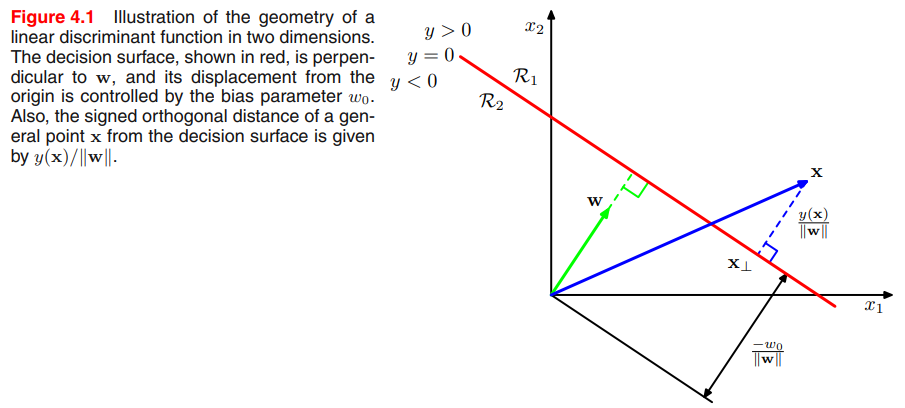

In [1]:
from IPython.display import Image
Image('figures/Figure4.1.png', width=800)
# Source: Bishop textbook

For a 2-class problem, we use the following **decision rule**:

\begin{align*}
\text{Decide }\begin{cases}\mathbf{x}\in C_1 & \text{if }\;\;y(\mathbf{x})>0\\\mathbf{x}\in C_2 & \text{if }\;\;y(\mathbf{x})<0\end{cases}
\end{align*}

---

We already saw an approach of solving for this mapper function, specifically the Least Squares solution for regression tasks.

We can use the LS solution for classification tasks (take class 1 if $y(x)>0$ or 0 otherwise). But, the Gaussianity assumptions (objective function modeled as the MSE function) no longer applies. Moreover, since the standard LS uses the MSE objective function, its goal is no minimize the error and will, thus, become very sensitive to points that are "outliers" but yet correctly classified (as seen in picture below).

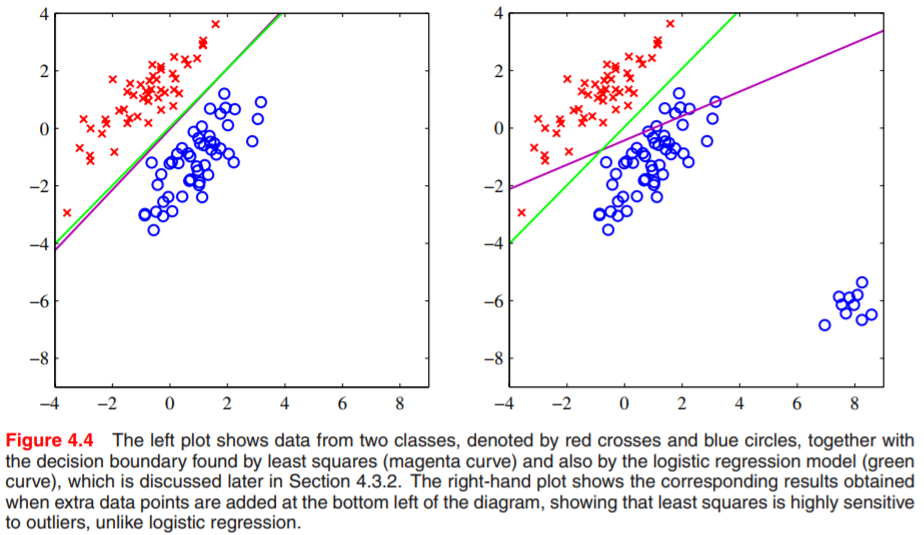

In [2]:
Image('figures/Figure4.4.png', width=800)
# Source: Bishop textbook

We will study 4 other methods to optimize the parameter $\mathbf{w}$ of a linear discriminant function (classifier), namely:

1. Fisher's Linear Discriminant Analysis (FLDA or LDA)
2. The Perceptron algorithm
3. Logistic Regression
4. Support Vector Machine (SVM)

---

# Fisher's Linear Discriminant Analysis (or LDA)

A very popular type of a linear discriminant is the **Fisher's Linear Discriminant**.

* Given two classes, we can compute the mean of each class:

\begin{align*}
\mathbf{\overrightarrow{m}}_1 &= \frac{1}{{N}_1}\sum_{n\in C_1} \mathbf{\overrightarrow{x}_n}\\
\mathbf{\overrightarrow{m}_2} &= \frac{1}{N_2}\sum_{n\in C_2} \mathbf{\overrightarrow{x}_n}
\end{align*}

We can maximize the separation of the means:

\begin{align*}
m_2 - m_1 = \mathbf{\overrightarrow{w}}^T(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)
\end{align*}

* $\mathbf{\overrightarrow{w}}^T\mathbf{\overrightarrow{x}}$ takes a $D$ dimensional data point and projects it down to 1-D with a weight sum of the original features. We want to find a weighting that maximizes the separation of the class means. 

* Not only do we want well separated means for each class, but we also want each class to be *compact* to minimize overlap between the classes. 

* Consider the *within class variance:*

\begin{align*}
s_k^2 = \sum_{n \in C_k} (y_n - m_k)^2 &= \sum_{n \in C_k} (\mathbf{\overrightarrow{w}}^T\mathbf{\overrightarrow{x}}_n - m_k)^2 \\
&= \mathbf{\overrightarrow{w}}^T \sum_{n \in C_k} (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}_k}) (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}_k})^T \mathbf{\overrightarrow{w}}
\end{align*}

* So, we want to minimize within class variance and maximize between class separability. How about the following objective function:

\begin{align*}
J(\mathbf{w}) &= \frac{(m_2 - m_1)^2}{s_1^2 + s_2^2}\\
      &= \frac{\mathbf{\overrightarrow{w}}^T(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)^T\mathbf{\overrightarrow{w}}}{\sum_{n \in C_1} (\mathbf{\overrightarrow{w}}^T\mathbf{\overrightarrow{x}}_n - m_1)^2 + \sum_{n \in C_2} (\mathbf{\overrightarrow{w}}^T\mathbf{\overrightarrow{x}}_n - m_2)^2}\\
	  &= \frac{\mathbf{\overrightarrow{w}}^T(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)^T\mathbf{\overrightarrow{w}}}{\mathbf{\overrightarrow{w}}^T\left(\sum_{n \in C_1} (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_1)^T + \sum_{n \in C_2} (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_2)(\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_2)^T\right)\mathbf{\overrightarrow{w}}}\\
	  &= \frac{\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}}}{\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}}}
\end{align*}

where

\begin{align*}
S_B = (\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)^T
\end{align*}

and 

\begin{align*}
S_W= \frac{1}{N_1}\sum_{n \in C_1} (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_1)^T + \frac{1}{N_2}\sum_{n \in C_2} (\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_2)(\mathbf{\overrightarrow{x}}_n - \mathbf{\overrightarrow{m}}_2)^T
\end{align*}

* Ok, so let's optimize:

\begin{align*}
\frac{\partial J(\mathbf{\overrightarrow{w}})}{\partial \mathbf{\overrightarrow{w}}} &= \frac{2(\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}})\mathbf{S}_B\mathbf{\overrightarrow{w}} - 2(\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}})\mathbf{S}_W\mathbf{\overrightarrow{w}}}{(\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}})^2} = 0 \\
0 &= \ \frac{\mathbf{S}_B\mathbf{\overrightarrow{w}}}{(\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}})} -\frac{(\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}})\mathbf{S}_W\mathbf{\overrightarrow{w}}}{(\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}})^2} \\
 (\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}})\mathbf{S}_B\mathbf{\overrightarrow{w}} &= (\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}})\mathbf{S}_W\mathbf{\overrightarrow{w}} \\
 \mathbf{S}_B \mathbf{\overrightarrow{w}} &= \frac{\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}}}{\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}}} \mathbf{S}_W\mathbf{\overrightarrow{w}}\\
 \mathbf{S}_W^{-1}\mathbf{S}_B\mathbf{\overrightarrow{w}} &= \lambda\mathbf{\overrightarrow{w}}
\end{align*}

where the scalar $\lambda = \frac{\mathbf{\overrightarrow{w}}^T\mathbf{S}_B\mathbf{\overrightarrow{w}}} { \mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}}}$

#### *Does this look familiar?*

This is the generalized eigenvalue problem!

* So the direction of projection correspond to the eigenvectors of $\mathbf{S}_W^{-1}\mathbf{S}_B$ with the largest eigenvalues.

The solution is easy when $S_w^{-1} = (\Sigma_1 + \Sigma_2)^{-1}$ exists.

In this case, if we use the definition of $S_B = (\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{m}}_2 - \mathbf{\overrightarrow{m}}_1)^T$:

\begin{align*}
S_W^{-1}S_B\mathbf{\overrightarrow{w}} &= \lambda\mathbf{\overrightarrow{w}}\\
S_W^{-1}(\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1)(\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1)^T\mathbf{\overrightarrow{w}} &= \lambda\mathbf{\overrightarrow{w}}
\end{align*}

Noting that $\alpha = (\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1)^T\mathbf{\overrightarrow{w}}$ is a constant, this can be written as:

$$S_W^{-1}(\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1) = \frac{\lambda}{\alpha}\mathbf{\overrightarrow{w}}$$

* Since we don't care about the magnitude of $\mathbf{\overrightarrow{w}}$:

$$\mathbf{\overrightarrow{w}}^* = S_W^{-1}(\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1) = (\Sigma_1 + \Sigma_2)^{-1}(\mathbf{\overrightarrow{m}}_2-\mathbf{\overrightarrow{m}}_1)$$

Make sure $\mathbf{\overrightarrow{w}}^*$ is a unit vector by taking: $\mathbf{\overrightarrow{w}}^* \leftarrow \frac{\mathbf{\overrightarrow{w}}^*}{\Vert\mathbf{\overrightarrow{w}}^*\Vert}$

* Note that if the within-class covariance, $S_W$, is isotropic, so that $S_W$ is proportional to the unit matrix, we find that $\mathbf{\overrightarrow{w}}$ is proportional to the difference of the class means.

* This result is known as *Fisher's linear discriminant*, although strictly it is not a discriminant but rather a specific choice of direction for projection of the data down to one dimension. However, the projected data can subsequently be used to construct a discriminant, by choosing a threshold $y_0$ so that we classify a new point as belonging to $C_1$ if $y(x) \geq y_0$ and classify it as belonging to $C_2$ otherwise.

Also, note that:
* For a classification problem with Gaussian classes of equal covariance $\Sigma_i=\Sigma$, the boundary is the plane of normal:
$$\mathbf{\overrightarrow{w}} = \Sigma^{-1}(\mathbf{\overrightarrow{m}}_i-\mathbf{\overrightarrow{m}}_j)$$

* If $\Sigma_2=\Sigma_1$, this is also the LDA solution.

This gives two different **interpretations** of LDA:

* It is optimal *if and only if* the classes are Gaussian and have equal covariance.

* A classifier on the LDA features, is equivalent to the boundary after the approximation of the data by two Gaussians with equal covariance.

The final discriminant decision boundary is $\mathbf{\overrightarrow{y}} = \mathbf{\overrightarrow{w}}^*\mathbf{\overrightarrow{x}} + w_0$

The *bias* term $w_0$ can be defined as:

$$w_0 = - \frac{1}{2}\left(\frac{1}{N_1}\sum_{n\in C_1}\overrightarrow{x}_n + \frac{1}{N_2}\sum_{n\in C_2}\overrightarrow{x}_n \right)^T\mathbf{\overrightarrow{w}}^*$$

* An extension to multi-class problems has a similar derivation.

**Limitations** of LDA:

1. LDA produces at most $C-1$ feature projections, where $C$ is the number of classes.

2. If the classification error estimates establish that more features are needed, some other method must be employed to provide those additional features.

3. LDA is a parametric method (it assumes unimodal Gaussian likelihoods).

4. If the distributions are significantly non-Gaussian, the LDA projections may not preserve complex structure in the data needed for classification.

5. LDA will also fail if discriminatory information is not in the mean but in the variance of the data.

A popular variant of LDA are the **Multi-Layer Perceptrons** (or MLPs).

---